In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

In [2]:
medicion = pd.read_csv('Measurements\\medicion_manual_polarimetro_ortogonal2.csv')
I_med_orth= medicion['voltaje']-0.00194
theta_orth = medicion['angulo']*np.pi/180
medicion.head()

,voltaje,angulo
0,0.003243,0
1,0.004017,2
2,0.005003,4
3,0.005880,6
4,0.006579,8


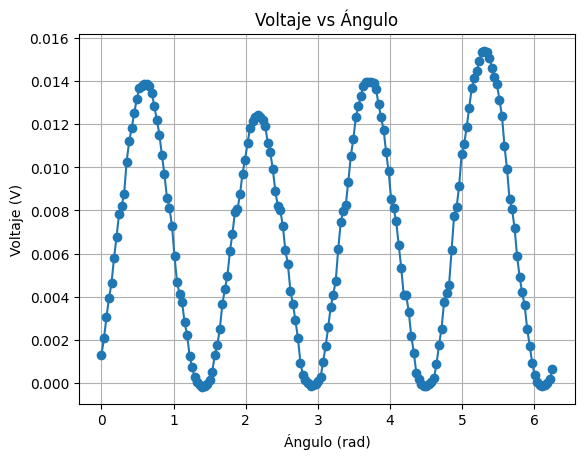

In [3]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta_orth, I_med_orth, 'o-')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

In [4]:
#we calculate the first minimum
min_idx = None

for i in range(1, len(I_med_orth)-1):
    if I_med_orth[i] < I_med_orth[i-1] and I_med_orth[i] < I_med_orth[i+1]:
        min_idx = i
        break

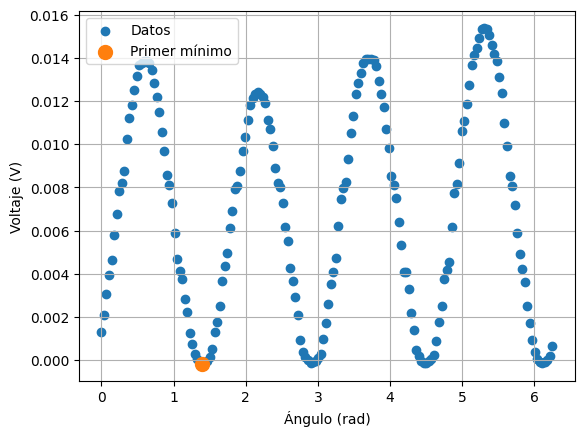

In [5]:
#we make sure we are defining correctly the lowest voltage
import matplotlib.pyplot as plt

plt.scatter(theta_orth, I_med_orth, label="Datos")

# marcar el mínimo
plt.scatter(theta_orth[min_idx], I_med_orth[min_idx],
            marker='o', s=100, label="Primer mínimo")

plt.xlabel("Ángulo (rad)")
plt.ylabel("Voltaje (V)")
plt.legend()
plt.grid()
plt.show()

In [6]:
theta_orth = theta_orth - theta_orth[min_idx]

In [7]:
#finally 
theta_orth = theta_orth[min_idx:].reset_index(drop=True)
I_med_orth = I_med_orth[min_idx:].reset_index(drop=True)

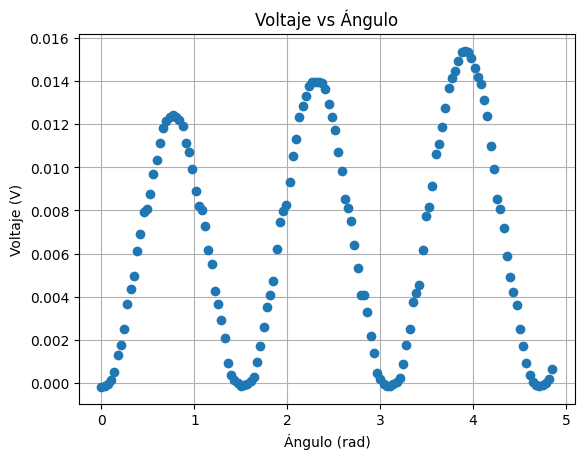

In [8]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta_orth, I_med_orth, 'o')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

In [9]:
#--- estimate S0 --- and normalize voltaje 
# # --- Identify peaks in the voltage data to select the mean as the normalization factor --- 
peaks_volt = find_peaks(I_med_orth)[0] 
peaks_angle = theta_orth[peaks_volt] 
norm_number = I_med_orth[peaks_volt].mean() 
display(f'Normalization number: {norm_number}') 
I_med = I_med_orth / norm_number

'Normalization number: 0.013920266666666667'

In [10]:
S0_orth = np.max(I_med_orth)
print(f'S0: {S0_orth}')

S0: 0.015392


In [11]:
#errors


theta_err_orth = np.deg2rad(2)     

V_div=0.005 #V
V_full_scale = 8 * V_div  
res_err = V_full_scale / 256

I_err_orth = np.sqrt((0.03 * I_med_orth)**2 + res_err**2)
I_err_orth = np.abs(I_err_orth)


S0 = 0.015392
S1 = -0.015391999999999998 ± 9.56403969280027e-05
S2 = 0.0016480204769198257 ± 0.00011870981670871194
S3 = 0.001690529689546884 ± 0.0006348581214731517

Deltas:
d1 = 2.25574483171609 ± 0.05128130060739719
d2 = 2.326771239994198 ± 0.06692284936763553
d3 = 3.394450392662624 ± 0.20534802162104918
d4 = 0.8757852372926896 ± 0.31654993027879025

DOP = 1.0116951003906411 ± 0.007644497168422349


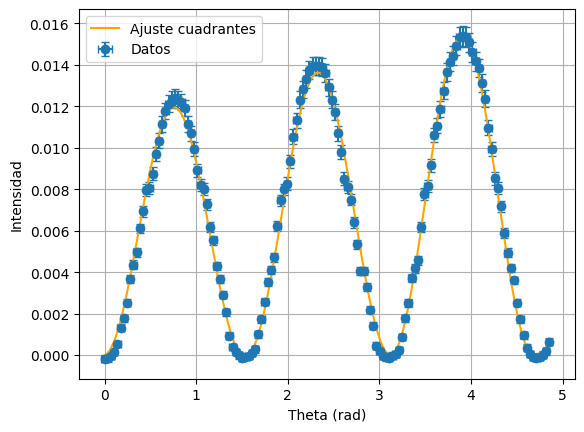

In [12]:
# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0_orth/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals con pesos ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return (model(theta_orth, S1, S2, S3, d1, d2, d3, d4) - I_med_orth) / I_err_orth

# --- initial conditions ---
initial_guess = [
    0.1*S0_orth,
    0.1*S0_orth,
    0.1*S0_orth,
    np.pi/2, np.pi/2, np.pi/2, np.pi/2
]

# --- bounds ---
lower_bounds = [-S0_orth, -S0_orth, -S0_orth, 0, 0, 0, 0]
upper_bounds = [ S0_orth,  S0_orth,  S0_orth, 2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

# --- errores de parámetros ---
J = result.jac
cov = np.linalg.pinv(J.T @ J) * np.sum(result.fun**2) / (len(I_med_orth) - len(result.x))
param_errors = np.sqrt(np.diag(cov))

S1_err, S2_err, S3_err, d1_err, d2_err, d3_err, d4_err = param_errors

# --- resultados ---
print("S0 =", S0_orth)
print(f"S1 = {S1_fit} ± {S1_err}")
print(f"S2 = {S2_fit} ± {S2_err}")
print(f"S3 = {S3_fit} ± {S3_err}")

print("\nDeltas:")
print(f"d1 = {d1_fit} ± {d1_err}")
print(f"d2 = {d2_fit} ± {d2_err}")
print(f"d3 = {d3_fit} ± {d3_err}")
print(f"d4 = {d4_fit} ± {d4_err}")

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0_orth

DOP_err = (1 / S0_orth) * np.sqrt(
    (S1_fit * S1_err)**2 +
    (S2_fit * S2_err)**2 +
    (S3_fit * S3_err)**2
) / np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2)

print(f"\nDOP = {DOP} ± {DOP_err}")

# --- fitted curve ---
theta_fit = np.linspace(theta_orth.min(), theta_orth.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- gráfico con errores ---
plt.errorbar(theta_orth, I_med_orth, yerr=I_err_orth, xerr=theta_err_orth,
             fmt='o', capsize=3, label="Datos")

plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

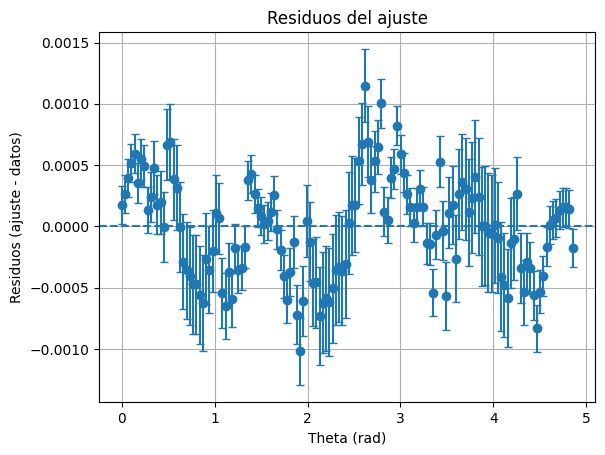

In [13]:
residuos = model(theta_orth, S1_fit, S2_fit, S3_fit,
                 d1_fit, d2_fit, d3_fit, d4_fit) - I_med_orth

plt.errorbar(theta_orth, residuos, yerr=I_err_orth, fmt='o', capsize=3)

plt.axhline(0, linestyle='--')

plt.xlabel("Theta (rad)")
plt.ylabel("Residuos (ajuste - datos)")
plt.title("Residuos del ajuste")

plt.grid()
plt.show()

In [14]:
# grados de libertad
N = len(I_med_orth)
p = len(result.x)
dof = N - p

# chi cuadrado
from scipy.stats import chi2
chi2_val = np.sum(result.fun**2)

# p-valor
p_value = 1 - chi2.cdf(chi2_val, dof)

print(f"Chi^2 = {chi2_val}")
print(f"grados de libertad = {dof}")
print(f"p-valor = {p_value}")

Chi^2 = 433.0334018336117
grados de libertad = 133
p-valor = 0.0


In [15]:
# --- vector de Stokes normalizado (Poincaré) ---
s1_orth = S1_fit / S0_orth
s2_orth= S2_fit / S0_orth
s3_orth = S3_fit / S0_orth

# --- errores ---
s1_err_orth = S1_err / S0_orth
s2_err_orth = S2_err / S0_orth
s3_err_orth = S3_err / S0_orth

print("\nVector de Poincaré:")
print(f"s1 = {s1_orth} ± {s1_err_orth}")
print(f"s2 = {s2_orth} ± {s2_err_orth}")
print(f"s3 = {s3_orth} ± {s3_err_orth}")


Vector de Poincaré:
s1 = -0.9999999999999999 ± 0.006213643251559427
s2 = 0.10706993742982236 ± 0.007712436116730246
s3 = 0.10983171059945973 ± 0.04124597982543865


In [16]:
s4=np.array([s1_orth,s2_orth,s3_orth])

In [18]:
def plot_poincare_sphere(ax, s_points):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    # ejes
    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    # --- plot de múltiples puntos ---
    for i, s in enumerate(s_points):
        ax.scatter(s[0], s[1], s[2], s=90, label=f"Point {i+1}")
        ax.plot([0, s[0]], [0, s[1]], [0, s[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()

In [19]:
s1=np.array([-0.8152544692898802 ,         0.628603213018236,  -0.10498477333323827] )
s2=np.array([ 0.9182177405184538, -0.14678916733408842,  -0.012863420529279104] )#curve fit de primeras med ort
s3=np.array([-0.82727437,  0.67022515 , 0.02815319])#curvefit first med de par


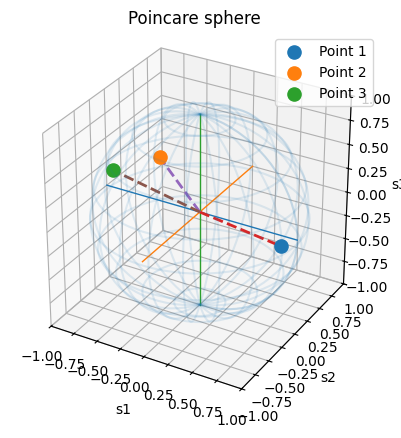

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plot_poincare_sphere(ax, [ s2, s3,s4])

plt.show()

## 3d 

In [22]:
def plot_poincare_sphere(ax, s1, s2):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    # ejes
    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    # --- vector 1 ---
    ax.scatter(s1[0], s1[1], s1[2], s=90, label="Orthogonal")
    ax.plot([0, s1[0]], [0, s1[1]], [0, s1[2]], "--", lw=2)

    # --- vector 2 ---
    ax.scatter(s2[0], s2[1], s2[2], s=90, label="Parallel")
    ax.plot([0, s2[0]], [0, s2[1]], [0, s2[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()

In [24]:
import matplotlib
matplotlib.use('TkAgg')

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

s1=np.array([-0.81525447,  0.62860321, -0.10498477])
s2=np.array([ 0.91821774 ,-0.14678917 ,-0.01286342])

plot_poincare_sphere(ax, s4, s2)

plt.show()